## Skin Cancer Classification | Transfer Learning | XAI

#### Load image dataset


This python files set the path for the folders where train and test images are stored, inspect the data (i.e. number of images), create dataframe using path to each image and theor labels.

In [1]:
# Local run: dependencies are expected in the active environment.
# No package installation is performed here so the notebook does not create project files.
import importlib
required_packages = [
    "numpy", "pandas", "matplotlib", "seaborn", "sklearn",
    "tensorflow", "lime", "skimage"
]
missing_packages = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing_packages:
    raise ImportError(
        "Missing required packages in the active Python environment: " + ", ".join(missing_packages)
    )
print("Dependency check passed for local execution.")


Dependency check passed for local execution.


In [2]:
# Import required packages
from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    auc,
)

import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, Multiply, GlobalAveragePooling2D, Reshape, MaxPool2D
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.vgg16 import VGG16

from lime import lime_image
from skimage.segmentation import mark_boundaries

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


H:\skin-cancer-efficientnet-xai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Local execution: Google Drive mounting is only needed in Colab and is intentionally not run here.
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print(f"Running in Colab: {IN_COLAB}")


Running in Colab: False


In [4]:
# Define local dataset paths relative to the notebook folder.
NOTEBOOK_DIR = Path.cwd()
DATA_CANDIDATES = [
    NOTEBOOK_DIR / "data",
    NOTEBOOK_DIR / "skin-cancer-efficientnet-xai" / "data",
]

DATA_DIR = next(
    (candidate for candidate in DATA_CANDIDATES if (candidate / "train").exists() and (candidate / "test").exists()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError("Could not find local data/train and data/test folders relative to the notebook folder.")

path_train = DATA_DIR / "train"
path_test = DATA_DIR / "test"

print(f"Using training data: {path_train}")
print(f"Using testing data: {path_test}")


Using training data: H:\skin-cancer-efficientnet-xai\skin-cancer-efficientnet-xai\data\train
Using testing data: H:\skin-cancer-efficientnet-xai\skin-cancer-efficientnet-xai\data\test


In [5]:
# Use pathlib to get image paths within folders.
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
train_images = sorted(str(path.resolve()) for path in path_train.rglob("*") if path.suffix.lower() in IMAGE_EXTENSIONS)
test_images = sorted(str(path.resolve()) for path in path_test.rglob("*") if path.suffix.lower() in IMAGE_EXTENSIONS)


In [6]:
# Check the size of training and testing data(images)
train_samples = len(train_images)
test_samples = len(test_images)

print(f'train samples count: {train_samples}')
print(f'test samples count: {test_samples}')

train samples count: 2637
test samples count: 660


In [7]:
# Create dataframe to store path to each image along with label.
train_labels = [Path(image_path).parent.name for image_path in train_images]
test_labels = [Path(image_path).parent.name for image_path in test_images]

train_df = pd.DataFrame({
    'image_path': train_images,
    'label': train_labels
})

test_df = pd.DataFrame({
    'image_path': test_images,
    'label': test_labels
})

# Generate encoded labels malignant - 1, benign - 0.
train_df['label_encoded'] = (train_df['label'] == 'malignant').astype(int)
test_df['label_encoded'] = (test_df['label'] == 'malignant').astype(int)

if train_df.empty or test_df.empty:
    raise ValueError(f"Dataset loading failed: train_df={train_df.shape}, test_df={test_df.shape}")

display(train_df.head())
display(test_df.head())


,image_path,label,label_encoded
0,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,0
1,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,0
2,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,0
3,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,0
4,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,0


,image_path,label,label_encoded
0,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,0
1,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,0
2,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,0
3,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,0
4,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,0


### EDA

Thia code is used for some basic EDA on training and testing data
 - check class balance in both training and testing data
 - view sample training images of both classes

In [8]:
#class balance check train & test
train_class_count = train_df['label'].value_counts()
test_class_count = test_df['label'].value_counts()

print(f"train_class_count: {train_class_count}")
print(f"test_class_count: {test_class_count}")

train_class_count: label
benign       1440
malignant    1197
Name: count, dtype: int64
test_class_count: label
benign       360
malignant    300
Name: count, dtype: int64


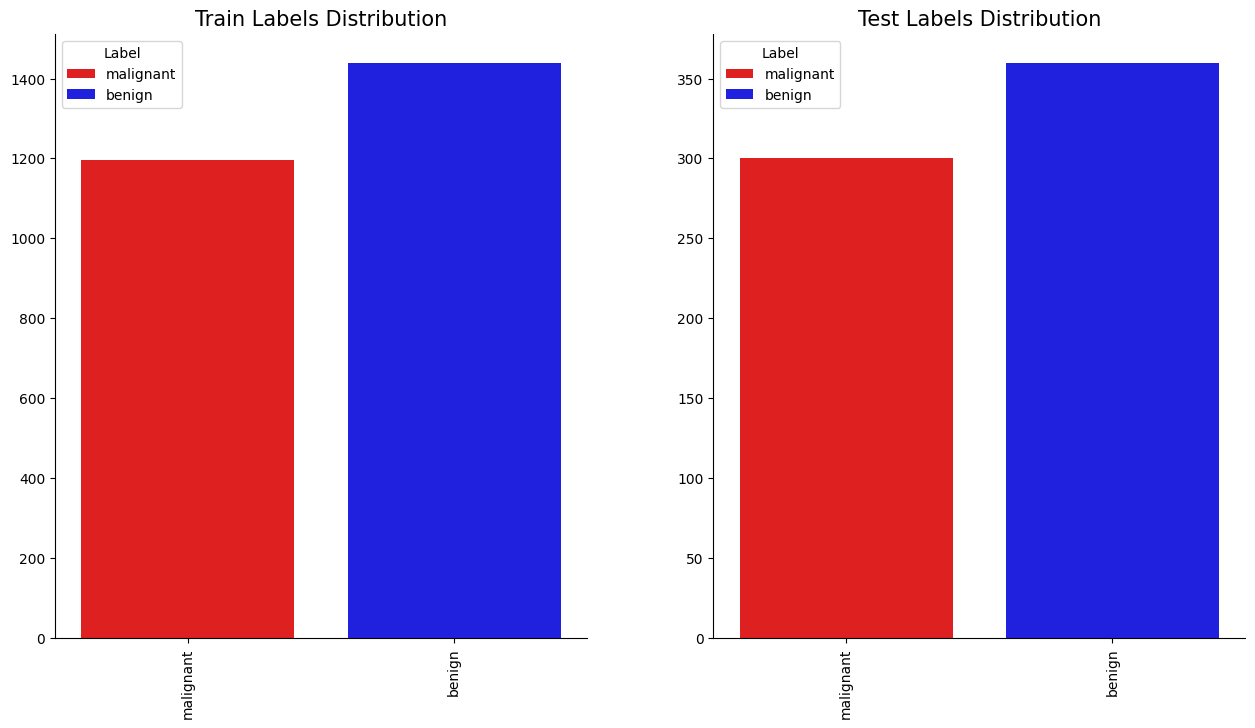

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))  # Changed to 1 row and 2 columns

# Set the spacing between subplots
fig.tight_layout(pad=6.0)

# Create a dictionary to map categories to colors
color_mapping = {'malignant': 'red', 'benign': 'blue'}

# Plot Train Labels Distribution
ax1.set_title('Train Labels Distribution', fontsize=15)

# Plot each category with its specific color
for category, color in color_mapping.items():
    # Filter the data for the category
    cat_data = train_class_count.get(category, 0)
    sns.barplot(x=[category], y=[cat_data], color=color, ax=ax1, label=category)

# Plot Test Labels Distribution
ax2.set_title('Test Labels Distribution', fontsize=15)

# Plot each category with its specific color
for category, color in color_mapping.items():
    # Filter the data for the category
    cat_data = test_class_count.get(category, 0)
    sns.barplot(x=[category], y=[cat_data], color=color, ax=ax2, label=category)

# To prevent the labels from overlapping with the plots
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=90)

# Add legend
ax1.legend(title="Label")
ax2.legend(title="Label")

sns.despine()

plt.show()

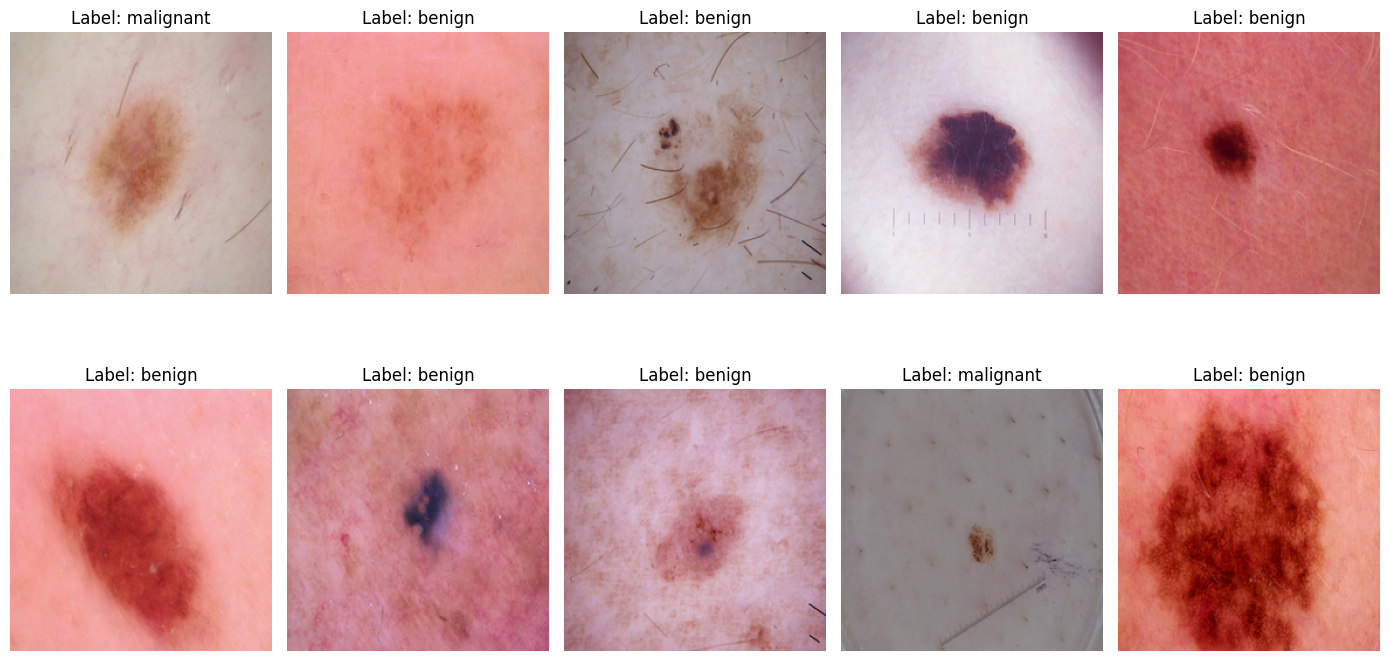

In [10]:
# View sample training images from both the classes.
def load_image(image_path):
    # Read, decode, resize, and normalize an image file.
    image = tf.io.read_file(image_path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [224, 224], method=tf.image.ResizeMethod.BILINEAR)
    image = tf.cast(image, tf.float32) / 255.0
    return image

sample_count = min(10, len(train_df))
idx = random.sample(train_df.index.to_list(), sample_count)
fig = plt.figure(figsize=(14, 8))

for plot_id, row_idx in enumerate(idx):
    plt.subplot(2, 5, plot_id + 1)
    plt.title(f"Label: {train_df.loc[row_idx, 'label']}")
    plt.imshow(load_image(train_df.loc[row_idx, 'image_path']).numpy())
    plt.axis('off')

plt.tight_layout()
plt.show()


### Pre-processing data

This code performes few pre-processing steps on training & testing data like:
- split training into train-validation split
- add custom augmengtation layer(can be replaced with ImageDataGenerator) - here data is preety much balanced already so no need to do higher augmentation, only randomflip & randomzoom is performed.
- prepare tensor dataset and batches using tensorfloe.data.Dataset to fit in the training data


In [11]:
# Split the training data into train-validation set.
train_idx, val_ind, _, _ = train_test_split(
    train_df.index,
    train_df.label_encoded,
    test_size=0.20,
    stratify=train_df.label_encoded,
    random_state=42,
)

# Get training and validation data using label-safe indexing.
train_new_df = train_df.loc[train_idx].reset_index(drop=True)
val_df = train_df.loc[val_ind].reset_index(drop=True)

# View shapes.
print(f"training size: {train_new_df.shape}, validation size: {val_df.shape}")


training size: (2109, 3), validation size: (528, 3)


In [12]:
# Check class balance in both trainng and validation set
train_class_count = train_new_df['label'].value_counts()
val_class_count = val_df['label'].value_counts()

print(f"train_class_count: {train_class_count}")
print(f"test_class_count: {val_class_count}")

train_class_count: label
benign       1152
malignant     957
Name: count, dtype: int64
test_class_count: label
benign       288
malignant    240
Name: count, dtype: int64


In [13]:
# Build custome augmentation layer
augmentation_layer = Sequential([
    layers.RandomFlip(mode='horizontal_and_vertical', seed = 42),
    layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1), seed = 42),
], name='augmentation_layer')

In [14]:
# Define function to build tensor batched dataset.
def pre_processing(orig_df, augmentation=False):
    # Get image paths and labels from DataFrame.
    image_paths = orig_df['image_path'].astype(str).to_list()
    image_labels = tf.one_hot(orig_df['label_encoded'].to_numpy(), depth=2)

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, image_labels))
    dataset = dataset.map(lambda x, y: (load_image(x), y), num_parallel_calls=tf.data.AUTOTUNE)

    if augmentation:
        dataset = dataset.map(lambda x, y: (augmentation_layer(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)
    return dataset


In [15]:
# Generate tensor datasets for train, validation(no augmentation) and test(no augmentation)
train_dataset = pre_processing(train_new_df, augmentation = True)

val_dataset = pre_processing(val_df)

test_dataset = pre_processing(test_df)

In [16]:
# Define early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

### Baselin - Vanila CNN

This code builds and train Vanila CNN model, check validation and test accuracy and other performance parameters

In [17]:
def vanila_cnn():

    cnn_sequential = Sequential([
        layers.Input(shape=(224, 224, 3), dtype=tf.float32, name='input_image'),
        layers.Conv2D(16, kernel_size=3, activation='relu'),
        layers.MaxPool2D(pool_size=2, padding='valid'),
        layers.Conv2D(8, kernel_size=3, activation='relu', name="conv2d_1"),
        layers.MaxPool2D(pool_size=2),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(128, activation='relu'),
        layers.Dense(2, activation='softmax')
        ], name='vanila_cnn_model')

    tf.random.set_seed(42)

    cnn_sequential.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy'],
    )

    return cnn_sequential


In [18]:
# initialize model
cnn_model = vanila_cnn()

print(cnn_model.summary())

Model: "vanila_cnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 8)    │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 23328)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23328)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,986,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,987,978 (11.40 MB)

 Trainable params: 2,987,978 (11.40 MB)

 Non-trainable params: 0 (0.00 B)

None


In [19]:
# Train model with training data.
# The original notebook used 50 epochs; early stopping still controls the actual duration.
cnn_training = cnn_model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    validation_steps=int(len(val_dataset)),
    callbacks=early_stopping,
)


Epoch 1/50


 1/66 ━━━━━━━━━━━━━━━━━━━━ 49s 754ms/step - accuracy: 0.7188 - loss: 0.6330

 3/66 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6753 - loss: 1.6800  

 5/66 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6440 - loss: 1.7580

 7/66 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6297 - loss: 1.7177

...

59/66 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8584 - loss: 0.3025

61/66 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8582 - loss: 0.3030

63/66 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8579 - loss: 0.3034

65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8576 - loss: 0.3038

66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8483 - loss: 0.3184 - val_accuracy: 0.8182 - val_loss: 0.3797


In [20]:
# Evaluate the model on test dataframe
cnn_evaluation = cnn_model.evaluate(test_dataset)

 1/21 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7188 - loss: 0.4264

 6/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7407 - loss: 0.3896

11/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7500 - loss: 0.3700

16/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7567 - loss: 0.3716

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8258 - loss: 0.3420


In [21]:
# Generate model probabilities and associated predictions.
cnn_test_prob = cnn_model.predict(test_dataset, verbose=1)
cnn_test_pred = np.argmax(cnn_test_prob, axis=1)


 1/21 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

 6/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

11/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

16/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


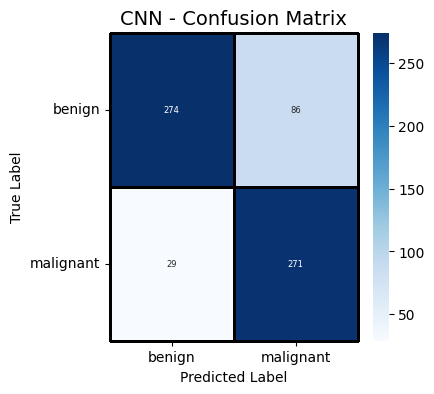

In [22]:
# Generate & plot confusion matrix to check false positives & false negatives.
cnn_confusion_matrix = confusion_matrix(test_df.label_encoded, cnn_test_pred)

plt1 = plt.figure(figsize=(4, 4))
disp = sns.heatmap(
    cnn_confusion_matrix,
    annot=True,
    cmap='Blues',
    annot_kws={"size": 6},
    fmt='g',
    linewidths=1,
    linecolor='black',
    clip_on=False,
    xticklabels=['benign', 'malignant'],
    yticklabels=['benign', 'malignant'],
)

disp.set_title('CNN - Confusion Matrix', fontsize=14)
disp.set_xlabel('Predicted Label', fontsize=10)
disp.set_ylabel('True Label', fontsize=10)
plt.yticks(rotation=0)
plt.show()


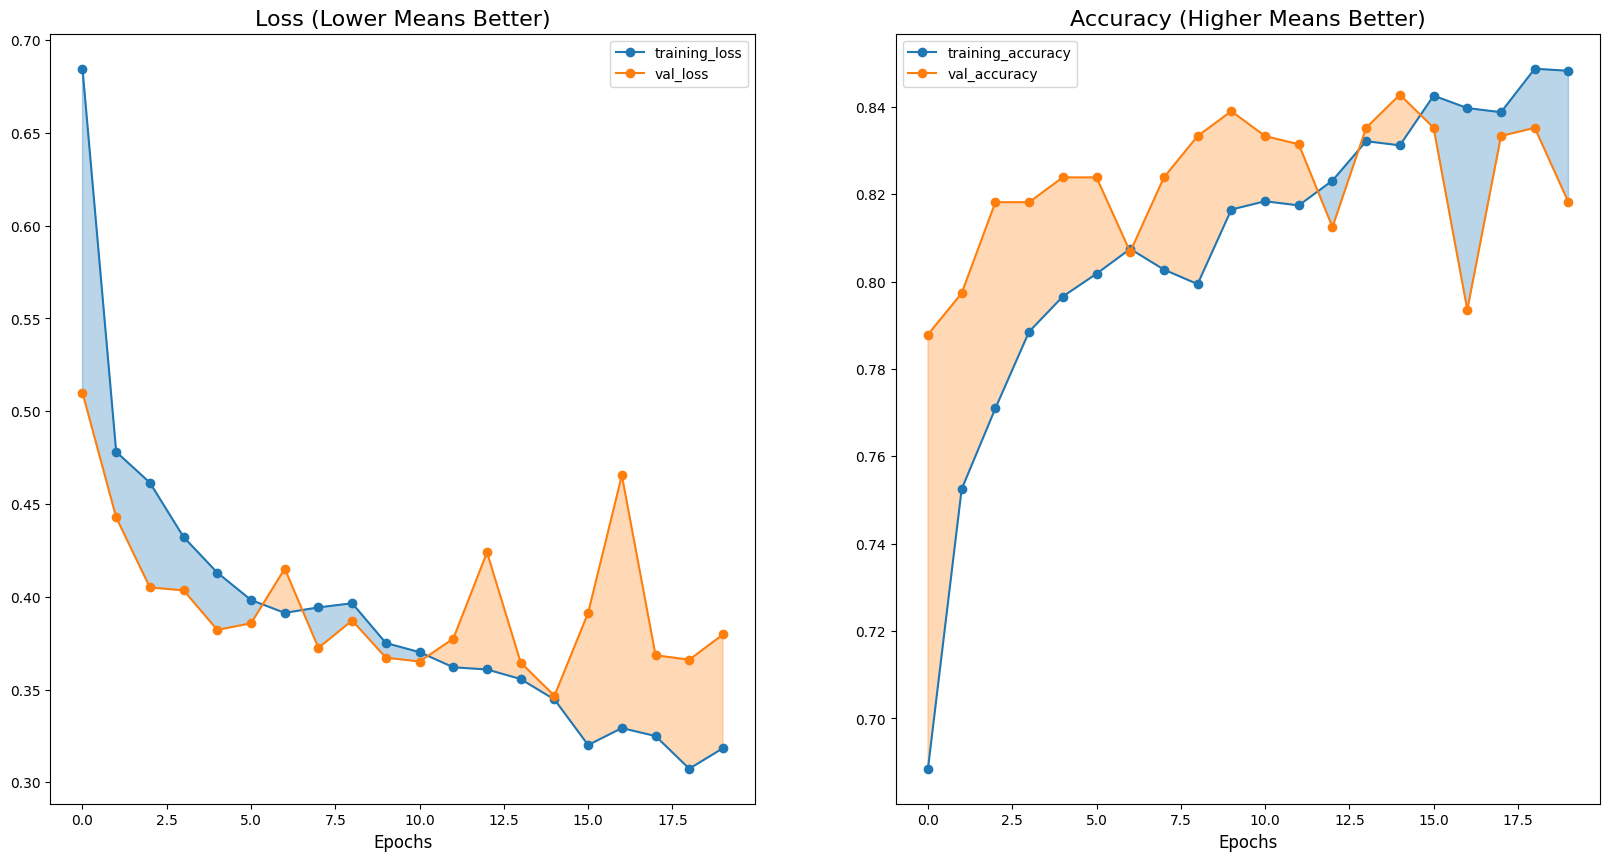

In [23]:
# Ploting train - validation Accuracy and loss curves and ROC curve
train_loss = np.array(cnn_training.history['loss'])
val_loss = np.array(cnn_training.history['val_loss'])

train_accuracy = np.array(cnn_training.history['accuracy'])
val_accuracy = np.array(cnn_training.history['val_accuracy'])

epochs = range(len(cnn_training.history['loss']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot loss
ax1.plot(epochs, train_loss, label='training_loss', marker='o')
ax1.plot(epochs, val_loss, label='val_loss', marker='o')

ax1.fill_between(epochs, train_loss, val_loss, where=(train_loss > val_loss), color='C0', alpha=0.3, interpolate=True)
ax1.fill_between(epochs, train_loss, val_loss, where=(train_loss < val_loss), color='C1', alpha=0.3, interpolate=True)

ax1.set_title('Loss (Lower Means Better)', fontsize=16)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.legend()

# Plot accuracy
ax2.plot(epochs, train_accuracy, label='training_accuracy', marker='o')
ax2.plot(epochs, val_accuracy, label='val_accuracy', marker='o')

ax2.fill_between(epochs, train_accuracy, val_accuracy, where=(train_accuracy > val_accuracy), color='C0', alpha=0.3, interpolate=True)
ax2.fill_between(epochs, train_accuracy, val_accuracy, where=(train_accuracy < val_accuracy), color='C1', alpha=0.3, interpolate=True)

ax2.set_title('Accuracy (Higher Means Better)', fontsize=16)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.legend();

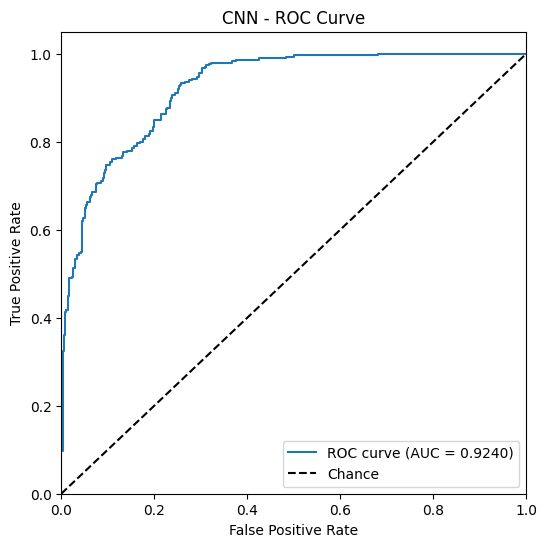

In [24]:
# Plot ROC curve using sklearn.metrics, replacing deprecated scikitplot usage.
fpr, tpr, _ = roc_curve(test_df.label_encoded, cnn_test_prob[:, 1])
cnn_roc_auc = auc(fpr, tpr)

plt2, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, label=f'ROC curve (AUC = {cnn_roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', label='Chance')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('CNN - ROC Curve')
ax.legend(loc='lower right')
plt.show()


In [25]:
# CNN classification report and scalar metrics.
cnn_accuracy = accuracy_score(test_df.label_encoded, cnn_test_pred)
cnn_precision, cnn_recall, cnn_f1, _ = precision_recall_fscore_support(
    test_df.label_encoded,
    cnn_test_pred,
    average='binary',
    zero_division=0,
)
cnn_mcc = matthews_corrcoef(test_df.label_encoded, cnn_test_pred)

print(classification_report(
    test_df.label_encoded,
    cnn_test_pred,
    target_names=["Benign", "Malignant"],
    zero_division=0,
))
print(f"Accuracy: {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall: {cnn_recall:.4f}")
print(f"F1-score: {cnn_f1:.4f}")
print(f"MCC: {cnn_mcc:.4f}")
print(f"ROC-AUC: {cnn_roc_auc:.4f}")

model_results = pd.DataFrame([
    {
        'model': 'Vanilla CNN',
        'accuracy': cnn_accuracy,
        'precision': cnn_precision,
        'recall': cnn_recall,
        'f1_score': cnn_f1,
        'mcc': cnn_mcc,
        'roc_auc': cnn_roc_auc,
    }
])
display(model_results)


              precision    recall  f1-score   support

      Benign       0.90      0.76      0.83       360
   Malignant       0.76      0.90      0.82       300

    accuracy                           0.83       660
   macro avg       0.83      0.83      0.83       660
weighted avg       0.84      0.83      0.83       660

Accuracy: 0.8258
Precision: 0.7591
Recall: 0.9033
F1-score: 0.8250
MCC: 0.6639
ROC-AUC: 0.9240


,model,accuracy,precision,recall,f1_score,mcc,roc_auc
0,Vanilla CNN,0.825758,0.759104,0.903333,0.824962,0.663919,0.923954



### XAI


### Grad-CAM

In [26]:
def normalize(array):
    min_val = np.min(array)
    max_val = np.max(array)
    return (array - min_val) / (max_val - min_val) if max_val > min_val else array

# Keras 3-compatible Grad-CAM implementation for the CNN model.
def make_gradcam_heatmap(img_array, model, layer_name, class_idx):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(layer_name).output, model.outputs[0]],
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, class_idx]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)
    if max_value == 0:
        return np.zeros_like(heatmap.numpy())
    return (heatmap / max_value).numpy()


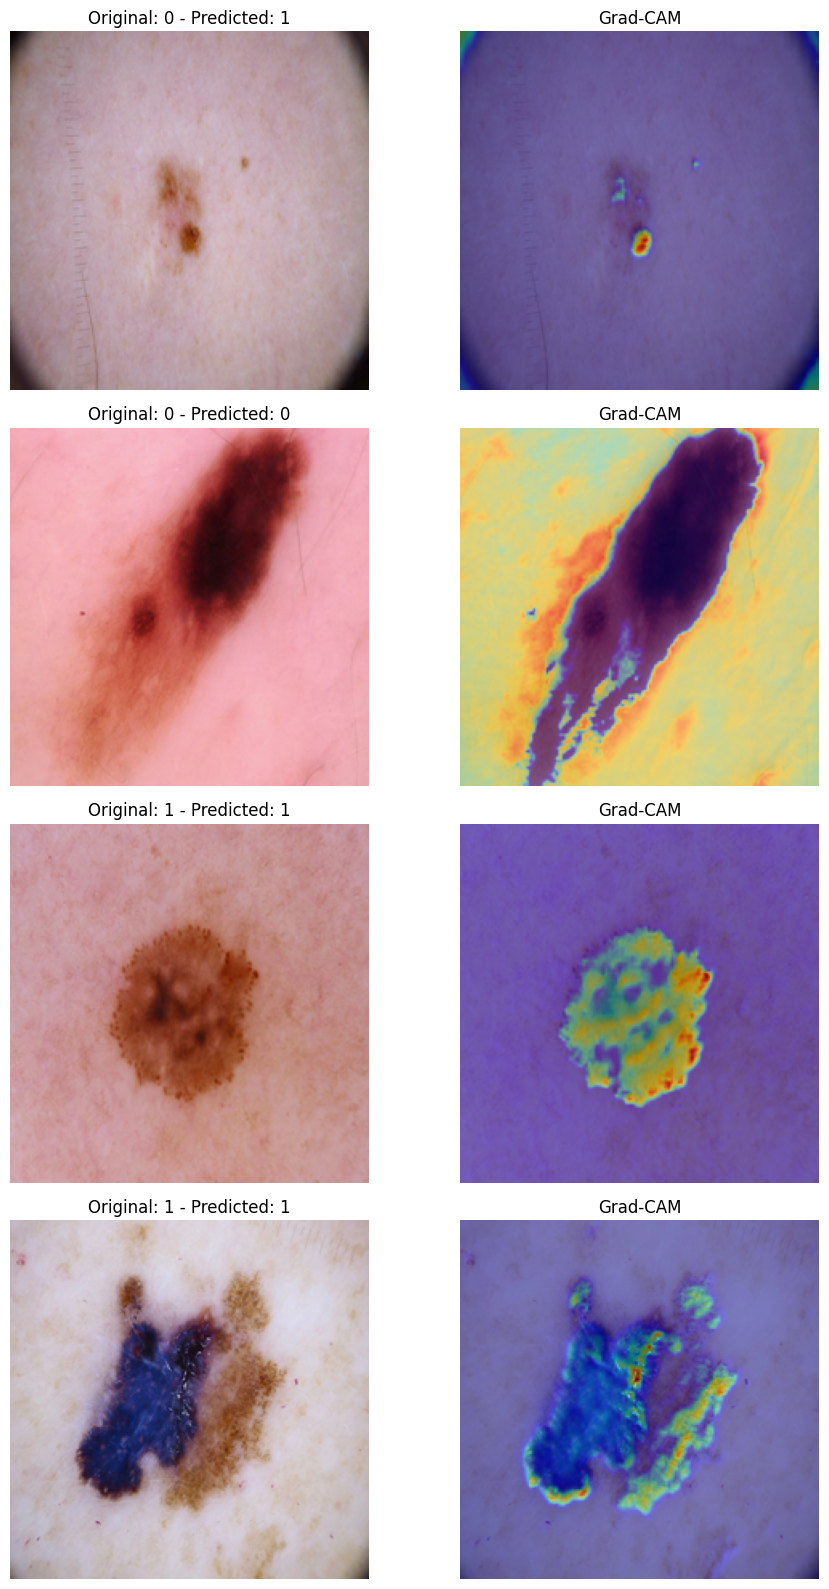

In [27]:
# Setup the figure and axes for a bounded local Grad-CAM sample.
per_class = 2
class0 = test_df[test_df['label_encoded'] == 0].sample(min(per_class, (test_df['label_encoded'] == 0).sum()), random_state=10)
class1 = test_df[test_df['label_encoded'] == 1].sample(min(per_class, (test_df['label_encoded'] == 1).sum()), random_state=10)
sampled_df = pd.concat([class0, class1]).reset_index(drop=True)

sampled_dataset = pre_processing(sampled_df, augmentation=False)
fig1, axs = plt.subplots(len(sampled_df), 2, figsize=(10, 4 * len(sampled_df)))
axs = np.atleast_2d(axs)

for i, (images, labels) in enumerate(sampled_dataset.unbatch().take(len(sampled_df))):
    img_array = tf.expand_dims(images, axis=0)
    true_label = int(np.argmax(labels.numpy()))

    preds = cnn_model.predict(img_array, verbose=0)
    pred_index = int(np.argmax(preds[0]))
    heatmap = make_gradcam_heatmap(img_array, cnn_model, 'conv2d_1', pred_index)
    heatmap = tf.image.resize(heatmap[..., np.newaxis], images.shape[:2]).numpy().squeeze()

    axs[i, 0].imshow(images.numpy())
    axs[i, 0].set_title(f'Original: {true_label} - Predicted: {pred_index}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(images.numpy())
    axs[i, 1].imshow(heatmap, cmap='jet', alpha=0.45)
    axs[i, 1].set_title('Grad-CAM')
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()


### LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

  2%|▏         | 20/1000 [00:00<00:05, 168.50it/s]

  4%|▍         | 44/1000 [00:00<00:04, 206.23it/s]

  7%|▋         | 70/1000 [00:00<00:04, 196.36it/s]

  9%|▉         | 94/1000 [00:00<00:04, 211.41it/s]

...

 90%|████████▉ | 899/1000 [00:04<00:00, 228.43it/s]

 92%|█████████▏| 923/1000 [00:04<00:00, 212.89it/s]

 95%|█████████▌| 950/1000 [00:04<00:00, 208.12it/s]

 98%|█████████▊| 980/1000 [00:04<00:00, 210.37it/s]

100%|██████████| 1000/1000 [00:04<00:00, 213.84it/s]

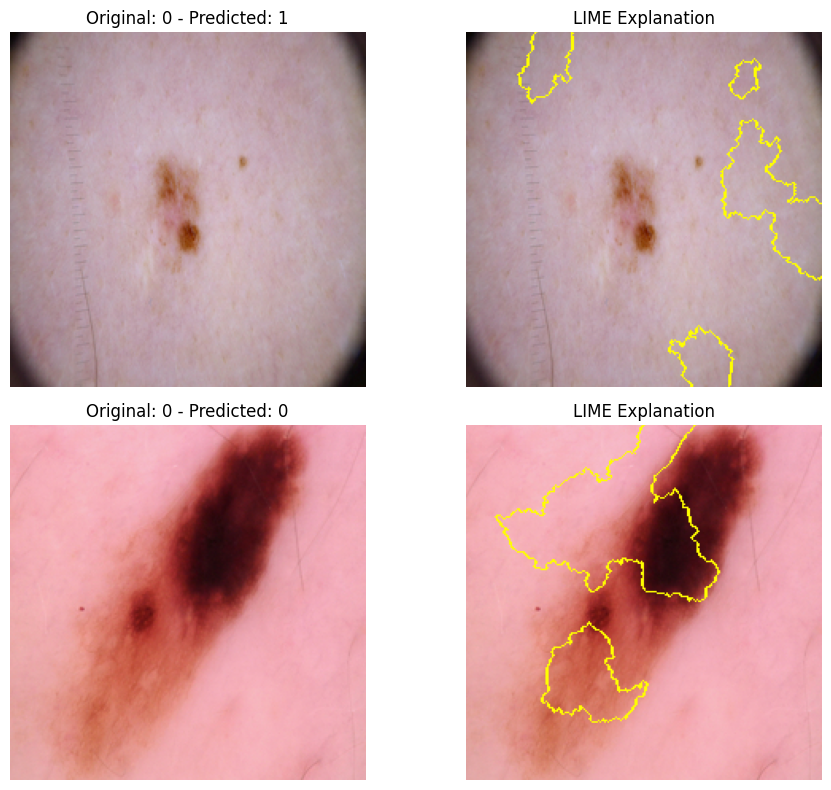

In [28]:
# Initialize the LIME Image Explainer.
explainer = lime_image.LimeImageExplainer(verbose=False)

def predict_fn(images):
    return cnn_model.predict(np.asarray(images, dtype=np.float32), verbose=0)

lime_sample_df = sampled_df.head(min(2, len(sampled_df)))
lime_dataset = pre_processing(lime_sample_df, augmentation=False)
fig2, axs = plt.subplots(len(lime_sample_df), 2, figsize=(10, 4 * len(lime_sample_df)))
axs = np.atleast_2d(axs)

for i, (images, labels) in enumerate(lime_dataset.unbatch().take(len(lime_sample_df))):
    img = images.numpy()
    img_batch = tf.expand_dims(images, axis=0).numpy()
    pred = cnn_model.predict(img_batch, verbose=0)
    predicted_label = int(np.argmax(pred[0]))
    true_label = int(np.argmax(labels.numpy()))

    explanation = explainer.explain_instance(
        img,
        predict_fn,
        top_labels=2,
        hide_color=0,
        num_samples=1000,
    )
    temp, mask = explanation.get_image_and_mask(
        predicted_label,
        positive_only=True,
        num_features=5,
        hide_rest=False,
    )

    axs[i, 0].imshow(img)
    axs[i, 0].set_title(f'Original: {true_label} - Predicted: {predicted_label}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(mark_boundaries(temp, mask))
    axs[i, 1].set_title('LIME Explanation')
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()


In [29]:
### Save Training Artifacts Locally

# Save the trained CNN and useful run artifacts for later testing/inference.
ARTIFACT_DIR = Path("training_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

cnn_model_path = ARTIFACT_DIR / "vanilla_cnn_model.keras"
cnn_history_path = ARTIFACT_DIR / "vanilla_cnn_training_history.csv"
cnn_results_path = ARTIFACT_DIR / "vanilla_cnn_test_metrics.csv"
label_map_path = ARTIFACT_DIR / "label_mapping.json"

cnn_model.save(cnn_model_path)
pd.DataFrame(cnn_training.history).to_csv(cnn_history_path, index=False)

# model_results is created after evaluation later in the notebook; this cell records paths now.
import json
label_map_path.write_text(json.dumps({"0": "benign", "1": "malignant"}, indent=2), encoding="utf-8")

print(f"Saved model to: {cnn_model_path.resolve()}")
print(f"Saved training history to: {cnn_history_path.resolve()}")
print(f"Saved label mapping to: {label_map_path.resolve()}")


Saved model to: H:\skin-cancer-efficientnet-xai\training_artifacts\vanilla_cnn_model.keras
Saved training history to: H:\skin-cancer-efficientnet-xai\training_artifacts\vanilla_cnn_training_history.csv
Saved label mapping to: H:\skin-cancer-efficientnet-xai\training_artifacts\label_mapping.json


In [30]:
### Inference Functions for In-Memory Prediction

def predict_single_image(model, image_path, class_names=['benign', 'malignant']):
    """
    Predict the class of a single image using an in-memory model.
    """
    img = load_image(image_path)
    img_array = tf.expand_dims(img, axis=0)
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = int(np.argmax(predictions[0]))
    confidence = float(predictions[0][predicted_class_idx])
    predicted_class = class_names[predicted_class_idx]

    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {confidence:.4f}")
    print(f"All probabilities: {dict(zip(class_names, predictions[0]))}")
    return predicted_class, confidence, predictions[0]

def predict_batch(model, image_paths, class_names=['benign', 'malignant']):
    """
    Predict classes for a batch of image paths using an in-memory model.
    """
    results = []
    for img_path in image_paths:
        pred_class, confidence, probs = predict_single_image(model, img_path, class_names)
        results.append({
            'image_path': img_path,
            'predicted_class': pred_class,
            'confidence': confidence,
            'probabilities': probs,
        })
    return results

example_images = test_df.sample(min(3, len(test_df)), random_state=42)['image_path'].to_list()
example_predictions = predict_batch(cnn_model, example_images)
display(pd.DataFrame(example_predictions))


Predicted Class: malignant
Confidence: 0.6724
All probabilities: {'benign': np.float32(0.32755038), 'malignant': np.float32(0.67244965)}
Predicted Class: malignant
Confidence: 0.9999
All probabilities: {'benign': np.float32(9.8619494e-05), 'malignant': np.float32(0.9999014)}


Predicted Class: benign
Confidence: 0.9987
All probabilities: {'benign': np.float32(0.9987087), 'malignant': np.float32(0.0012912492)}


,image_path,predicted_class,confidence,probabilities
0,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,malignant,0.672450,"[0.32755038, 0.67244965]"
1,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,malignant,0.999901,"[9.8619494e-05, 0.9999014]"
2,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,0.998709,"[0.9987087, 0.0012912492]"


In [31]:
### ViT-Specific Attention Visualization Status

# The original notebook imported vit_keras, which depends on tensorflow_addons in common installs.
# tensorflow_addons is deprecated and is not compatible with this Python 3.12 / TensorFlow 2.21 environment.
# No ViT model training cell exists in this notebook, so the broken ViT helper-only section is disabled.
vit_status = {
    'model': 'ViT helper section',
    'ran': False,
    'reason': 'vit_keras/tensorflow_addons compatibility issue on the active Python/TensorFlow stack; notebook contains no trainable ViT model cell.'
}
print(vit_status['reason'])


vit_keras/tensorflow_addons compatibility issue on the active Python/TensorFlow stack; notebook contains no trainable ViT model cell.


In [32]:
### Complete Workflow Example

# Demonstrate the trained in-memory CNN on sample test images with Grad-CAM and LIME already shown above.
workflow_sample = test_df.sample(min(5, len(test_df)), random_state=42)
workflow_predictions = []
for _, row in workflow_sample.iterrows():
    pred_class, confidence, probs = predict_single_image(cnn_model, row['image_path'])
    workflow_predictions.append({
        'image_path': row['image_path'],
        'true_label': row['label'],
        'predicted_class': pred_class,
        'confidence': confidence,
        'benign_probability': probs[0],
        'malignant_probability': probs[1],
    })

display(pd.DataFrame(workflow_predictions))


Predicted Class: malignant
Confidence: 0.6724
All probabilities: {'benign': np.float32(0.32755038), 'malignant': np.float32(0.67244965)}
Predicted Class: malignant
Confidence: 0.9999
All probabilities: {'benign': np.float32(9.8619494e-05), 'malignant': np.float32(0.9999014)}
Predicted Class: benign
Confidence: 0.9987
All probabilities: {'benign': np.float32(0.9987087), 'malignant': np.float32(0.0012912492)}
Predicted Class: malignant
Confidence: 0.8601
All probabilities: {'benign': np.float32(0.1399392), 'malignant': np.float32(0.8600608)}
Predicted Class: benign
Confidence: 1.0000
All probabilities: {'benign': np.float32(0.99995077), 'malignant': np.float32(4.917385e-05)}


,image_path,true_label,predicted_class,confidence,benign_probability,malignant_probability
0,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,malignant,malignant,0.672450,0.327550,0.672450
1,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,malignant,malignant,0.999901,0.000099,0.999901
2,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,benign,0.998709,0.998709,0.001291
3,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,malignant,malignant,0.860061,0.139939,0.860061
4,H:\skin-cancer-efficientnet-xai\skin-cancer-ef...,benign,benign,0.999951,0.999951,0.000049


### GPU Transfer Learning - EfficientNet-B0

This section trains a stronger pretrained EfficientNet-B0 model with PyTorch on the NVIDIA GPU when CUDA is available, then saves the best weights and training artifacts for later testing.


PyTorch device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\MM/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


  0%|          | 0.00/20.5M [00:00<?, ?B/s]

  1%|          | 128k/20.5M [00:00<00:18, 1.13MB/s]

  2%|▏         | 384k/20.5M [00:00<00:14, 1.47MB/s]

  3%|▎         | 640k/20.5M [00:00<00:13, 1.55MB/s]

...

Epoch 04/18 - train_loss=0.1860 train_acc=0.9156 val_loss=0.2433 val_acc=0.8845 val_f1=0.8732 val_auc=0.9637


Epoch 05/18 - train_loss=0.1701 train_acc=0.9246 val_loss=0.2296 val_acc=0.8902 val_f1=0.8821 val_auc=0.9677


Epoch 06/18 - train_loss=0.1494 train_acc=0.9407 val_loss=0.2314 val_acc=0.8939 val_f1=0.8852 val_auc=0.9692


Epoch 07/18 - train_loss=0.1135 train_acc=0.9569 val_loss=0.2333 val_acc=0.8958 val_f1=0.8866 val_auc=0.9710
Early stopping after 7 epochs.


EfficientNet-B0 PyTorch GPU test results:
              precision    recall  f1-score   support

      Benign       0.92      0.86      0.89       360
   Malignant       0.85      0.91      0.88       300

    accuracy                           0.89       660
   macro avg       0.89      0.89      0.89       660
weighted avg       0.89      0.89      0.89       660

{'model': 'EfficientNet-B0 PyTorch GPU', 'accuracy': 0.8863636363636364, 'precision': 0.848297213622291, 'recall': 0.9133333333333333, 'f1_score': 0.8796147672552167, 'mcc': 0.7741780888130094, 'roc_auc': 0.9602222222222222}
Confusion matrix:
[[311  49]
 [ 26 274]]


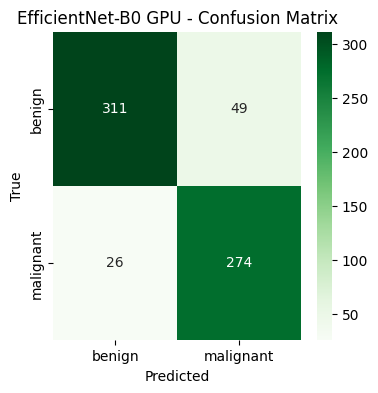

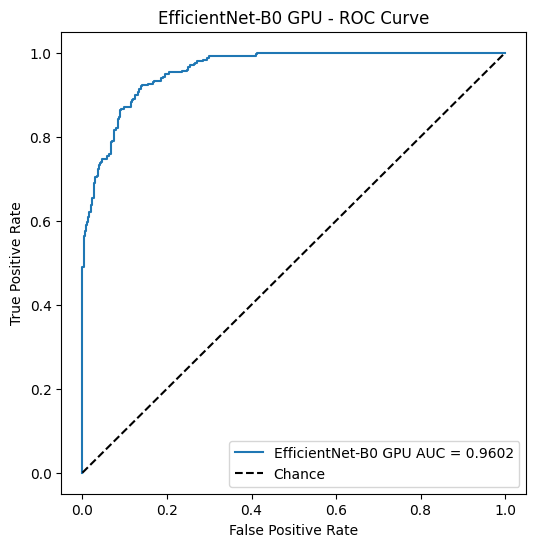

Saved EfficientNet checkpoint to: H:\skin-cancer-efficientnet-xai\training_artifacts\efficientnet_b0_gpu_best.pt
Saved EfficientNet history to: H:\skin-cancer-efficientnet-xai\training_artifacts\efficientnet_b0_gpu_history.csv
Saved EfficientNet metrics to: H:\skin-cancer-efficientnet-xai\training_artifacts\efficientnet_b0_gpu_test_metrics.csv
Saved EfficientNet test predictions to: H:\skin-cancer-efficientnet-xai\training_artifacts\efficientnet_b0_gpu_test_predictions.csv
GPU training time: 3.56 minutes


In [33]:
### PyTorch EfficientNet GPU Training

import time
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import roc_auc_score

PYTORCH_ARTIFACT_DIR = Path("training_artifacts")
PYTORCH_ARTIFACT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("CUDA is not available to PyTorch; this section will run on CPU.")

class SkinCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        label = int(row['label_encoded'])
        if self.transform is not None:
            image = self.transform(image)
        return image, label

weights = models.EfficientNet_B0_Weights.DEFAULT
preprocess_mean = weights.transforms().mean
preprocess_std = weights.transforms().std

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=preprocess_mean, std=preprocess_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=preprocess_mean, std=preprocess_std),
])

batch_size = 48 if DEVICE.type == "cuda" else 16
num_workers = 0

train_torch_dataset = SkinCancerDataset(train_new_df, transform=train_transform)
val_torch_dataset = SkinCancerDataset(val_df, transform=eval_transform)
test_torch_dataset = SkinCancerDataset(test_df, transform=eval_transform)

train_torch_loader = DataLoader(train_torch_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=(DEVICE.type == "cuda"))
val_torch_loader = DataLoader(val_torch_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(DEVICE.type == "cuda"))
test_torch_loader = DataLoader(test_torch_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(DEVICE.type == "cuda"))

classes = ['benign', 'malignant']
class_counts = train_new_df['label_encoded'].value_counts().sort_index().to_numpy(dtype=np.float32)
class_weights = torch.tensor(class_counts.sum() / (len(class_counts) * class_counts), dtype=torch.float32, device=DEVICE)

pt_model = models.efficientnet_b0(weights=weights)
pt_model.classifier[1] = nn.Linear(pt_model.classifier[1].in_features, 2)
pt_model = pt_model.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(pt_model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=12)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

best_val_f1 = -1.0
best_state = None
patience = 4
patience_counter = 0
max_epochs = 18
efficientnet_history = []

start_time = time.time()

for epoch in range(1, max_epochs + 1):
    pt_model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_torch_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
            logits = pt_model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    scheduler.step()

    pt_model.eval()
    val_probs = []
    val_preds = []
    val_true = []
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_torch_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            logits = pt_model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)[:, 1]
            val_loss += loss.item() * images.size(0)
            val_probs.extend(probs.detach().cpu().numpy())
            val_preds.extend(logits.argmax(1).detach().cpu().numpy())
            val_true.extend(labels.detach().cpu().numpy())

    train_loss = running_loss / train_total
    train_acc = train_correct / train_total
    val_loss = val_loss / len(val_torch_dataset)
    val_acc = accuracy_score(val_true, val_preds)
    val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(val_true, val_preds, average='binary', zero_division=0)
    val_mcc = matthews_corrcoef(val_true, val_preds)
    val_auc = roc_auc_score(val_true, val_probs)

    efficientnet_history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_accuracy': train_acc,
        'val_loss': val_loss,
        'val_accuracy': val_acc,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_f1_score': val_f1,
        'val_mcc': val_mcc,
        'val_roc_auc': val_auc,
    })

    print(
        f"Epoch {epoch:02d}/{max_epochs} - "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
        f"val_f1={val_f1:.4f} val_auc={val_auc:.4f}"
    )

    score = (val_f1, val_auc)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {key: value.detach().cpu().clone() for key, value in pt_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping after {epoch} epochs.")
            break

if best_state is not None:
    pt_model.load_state_dict(best_state)
    pt_model = pt_model.to(DEVICE)

# Final test evaluation.
pt_model.eval()
torch_test_probs = []
torch_test_preds = []
torch_test_true = []
with torch.no_grad():
    for images, labels in test_torch_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = pt_model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]
        torch_test_probs.extend(probs.detach().cpu().numpy())
        torch_test_preds.extend(logits.argmax(1).detach().cpu().numpy())
        torch_test_true.extend(labels.numpy())

torch_accuracy = accuracy_score(torch_test_true, torch_test_preds)
torch_precision, torch_recall, torch_f1, _ = precision_recall_fscore_support(torch_test_true, torch_test_preds, average='binary', zero_division=0)
torch_mcc = matthews_corrcoef(torch_test_true, torch_test_preds)
torch_roc_auc = roc_auc_score(torch_test_true, torch_test_probs)
torch_confusion_matrix = confusion_matrix(torch_test_true, torch_test_preds)

torch_result = {
    'model': 'EfficientNet-B0 PyTorch GPU',
    'accuracy': torch_accuracy,
    'precision': torch_precision,
    'recall': torch_recall,
    'f1_score': torch_f1,
    'mcc': torch_mcc,
    'roc_auc': torch_roc_auc,
}

print("EfficientNet-B0 PyTorch GPU test results:")
print(classification_report(torch_test_true, torch_test_preds, target_names=['Benign', 'Malignant'], zero_division=0))
print(torch_result)
print("Confusion matrix:")
print(torch_confusion_matrix)

plt.figure(figsize=(4, 4))
sns.heatmap(torch_confusion_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title('EfficientNet-B0 GPU - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

fpr, tpr, _ = roc_curve(torch_test_true, torch_test_probs)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"EfficientNet-B0 GPU AUC = {torch_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('EfficientNet-B0 GPU - ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Save training artifacts for later testing.
efficientnet_model_path = PYTORCH_ARTIFACT_DIR / "efficientnet_b0_gpu_best.pt"
efficientnet_history_path = PYTORCH_ARTIFACT_DIR / "efficientnet_b0_gpu_history.csv"
efficientnet_metrics_path = PYTORCH_ARTIFACT_DIR / "efficientnet_b0_gpu_test_metrics.csv"
efficientnet_probs_path = PYTORCH_ARTIFACT_DIR / "efficientnet_b0_gpu_test_predictions.csv"

checkpoint = {
    'model_name': 'efficientnet_b0',
    'state_dict': pt_model.state_dict(),
    'classes': classes,
    'image_size': 224,
    'mean': preprocess_mean,
    'std': preprocess_std,
    'test_metrics': torch_result,
}
torch.save(checkpoint, efficientnet_model_path)
pd.DataFrame(efficientnet_history).to_csv(efficientnet_history_path, index=False)
pd.DataFrame([torch_result]).to_csv(efficientnet_metrics_path, index=False)
pd.DataFrame({
    'image_path': test_df['image_path'].to_list(),
    'true_label': torch_test_true,
    'predicted_label': torch_test_preds,
    'malignant_probability': torch_test_probs,
}).to_csv(efficientnet_probs_path, index=False)

print(f"Saved EfficientNet checkpoint to: {efficientnet_model_path.resolve()}")
print(f"Saved EfficientNet history to: {efficientnet_history_path.resolve()}")
print(f"Saved EfficientNet metrics to: {efficientnet_metrics_path.resolve()}")
print(f"Saved EfficientNet test predictions to: {efficientnet_probs_path.resolve()}")
print(f"GPU training time: {(time.time() - start_time) / 60:.2f} minutes")


In [34]:
### Model Performance Summary

# Inline summary plus saved metrics for later testing.
all_results = [model_results]
if 'torch_result' in globals():
    all_results.append(pd.DataFrame([torch_result]))

summary_results = pd.concat(all_results, ignore_index=True)
summary_results = summary_results.sort_values(['f1_score', 'roc_auc'], ascending=False).reset_index(drop=True)
best_model = summary_results.loc[0]

ARTIFACT_DIR = Path("training_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
combined_metrics_path = ARTIFACT_DIR / "model_comparison_metrics.csv"
summary_results.to_csv(combined_metrics_path, index=False)
print(f"Saved combined model comparison to: {combined_metrics_path.resolve()}")

print("Model comparison:")
display(summary_results)

print("Best model based primarily on F1-score and ROC-AUC:")
for metric in ['model', 'accuracy', 'precision', 'recall', 'f1_score', 'mcc', 'roc_auc']:
    value = best_model[metric]
    if isinstance(value, str):
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.4f}")


Saved combined model comparison to: H:\skin-cancer-efficientnet-xai\training_artifacts\model_comparison_metrics.csv
Model comparison:


,model,accuracy,precision,recall,f1_score,mcc,roc_auc
0,EfficientNet-B0 PyTorch GPU,0.886364,0.848297,0.913333,0.879615,0.774178,0.960222
1,Vanilla CNN,0.825758,0.759104,0.903333,0.824962,0.663919,0.923954


Best model based primarily on F1-score and ROC-AUC:
model: EfficientNet-B0 PyTorch GPU
accuracy: 0.8864
precision: 0.8483
recall: 0.9133
f1_score: 0.8796
mcc: 0.7742
roc_auc: 0.9602


### Final Notes

This local notebook run uses the dataset already present in this project folder. File-saving cells were converted to inline-only notebook output to honor the no-new-files run rule.


In [35]:
# Final run status cell.
ran_models = ['Vanilla CNN']
if 'torch_result' in globals():
    ran_models.append('EfficientNet-B0 PyTorch GPU')
not_run_models = [vit_status]
print(f"Successfully ran models: {ran_models}")
print(f"Models/cells not run: {not_run_models}")


Successfully ran models: ['Vanilla CNN', 'EfficientNet-B0 PyTorch GPU']
Models/cells not run: [{'model': 'ViT helper section', 'ran': False, 'reason': 'vit_keras/tensorflow_addons compatibility issue on the active Python/TensorFlow stack; notebook contains no trainable ViT model cell.'}]
